# Mandatory: Artificial Neural Networks 
## Building a ANN from Scratch in Python
In this tutorial, we will build a simple Artificial Neural Network (ANN) from scratch using Python.  
The purpose for this exersize is to aquire a deeper understanding of how ANNs are structured, before implementing the same consepts with ANN libraries like `TensorFlow` an `PyTorch`.  

The work preformed in this notebook is inspired from the article "[Building Artificial Neural Networks (ANN) from Scratch](https://www.geeksforgeeks.org/deep-learning/building-artificial-neural-networks-ann-from-scratch/)", which is an instructional article on how to build a functioning ANN machine without pre-defined libraries.  

To further understand the content of the article and its content, I've used `Chat GPT`([ANN conversation](https://chatgpt.com/share/6920acb1-0e78-800e-beb9-10212bd96007), [numpy explanations](https://chatgpt.com/share/6920ae0f-4b18-800e-bb3c-3b497c7a267d)) as a companion assistant to explain how the code is tied togheter and how certain mathematical function in the `numpy` library works.

### Package Import
As mentioned above this notebook contains a minimum of packages to make the solution functional.  
The imported libraries are only intended to solve or simplify longer prosesses like mathematical calculation, import of data and partitioning of data into train and test partiotions.

**Packages:**
* numpy - Used to simplify mathematical challenges which would be quite demaninding to do manually.
* pandas - Used for import of data and simple data manipulations, like one-hot encoding etc.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

### Functions
Since we're not going to relay on pre-defined libraries for this exersize, it's necessary to create our own library to compensate for this. The following cells contains different functions which will be used to build a final training function for the ANN machine.  

Cells below consists of following topics:
- Train, Validation and Test Split.
- Initial Parameters.
- Activation Functions.
- Forward Propagation.
- Computing Cost.
- Backpropagation.
- Updating Parameter.
- Model Training.
- Making Predictions.

#### Train, Test and Split.
Here we use a pre-written function which has been used in earlier assigments.  
This functions let's us effectivly divide provided data into `train`, `validation` and `test` partitions.  

I've added a small change to the function this round, so if no size is defined for the validation (default), then it will only return `train` and `test` partitions for the dataset.  

By default the random seed is set to `None` which makes the split random at each run. For instances where reproducibility is important, this value should be defined with a numeric value.  

Stratification is oriented around a single target column, so this function will work properly on datasets that consists of binary/multiclass classifications, but not on multilabel classifications with more than one target column.

In [90]:
def stvts(df, target_col, test_size=0.2, val_size=0.0, random_state=None):
    # 1. Split into train+val and test
    train_val, test = train_test_split(
        df,
        test_size=test_size,
        stratify=df[target_col],
        random_state=random_state
    )
    if val_size > 0:
        # 2. Split train+val into train and validation
        relative_val_size = val_size / (1 - test_size) 
        train, val = train_test_split(
            train_val,
            test_size=relative_val_size,
            stratify=train_val[target_col],
            random_state=random_state
        )
        # 3. Verify stratification
        print("Training set class distribution:")
        print(train[target_col].value_counts()/train.shape[0])
        print("Validation set class distribution:")
        print(val[target_col].value_counts()/val.shape[0])
        print("Test set class distribution:")
        print(test[target_col].value_counts()/test.shape[0],"\n")

        # 4. Separate features (X) and labels (y)
        X_train, y_train = train.drop(columns=[target_col]), train[target_col]
        X_val, y_val     = val.drop(columns=[target_col]), val[target_col]
        X_test, y_test   = test.drop(columns=[target_col]), test[target_col]

        # 5. print shapes of the splits
        print(f"Train set shape:\n {X_train.shape}, {y_train.shape}")
        print(f"Validation set shape:\n {X_val.shape}, {y_val.shape}")
        print(f"Test set shape:\n {X_test.shape}, {y_test.shape}")

        # 6. return the splits
        return X_train, X_val, X_test, y_train, y_val, y_test
    else:
        # 2. Remove Validation
        train = train_val

        # 3. Verify stratification
        print("Training set class distribution:")
        print(train[target_col].value_counts()/train.shape[0])
        print("Test set class distribution:")
        print(test[target_col].value_counts()/test.shape[0],"\n")

        # 4. Separate features (X) and labels (y)
        X_train, y_train = train.drop(columns=[target_col]), train[target_col]
        X_test, y_test   = test.drop(columns=[target_col]), test[target_col]

        # 5. print shapes of the splits
        print(f"Train set shape:\n {X_train.shape}, {y_train.shape}")
        print(f"Test set shape:\n {X_test.shape}, {y_test.shape}")

        # 6. return the splits
        return X_train, X_test, y_train, y_test

#### Initial Parameters.
This cell contains a function for the initial parameters for the model.  
These are the parameters which a model use as a base for training the model on the given dataset.  
The randomization for initialization has been set to a static seed values. This is to ensure that each run start with the same random seed to ensure reproducibility on the machine training stage.  

The function creates a dictionary that contains the following:
- Weights (`W1`, `W2`) -- Initialized with small random values scaled by $0.01$ to prevent large initial weights. The initial weight values will be defined based on the number of neuron assigned to the input, hidden and output layer in the neural network, which defines the shape of each weight.
- Biases (`b1`, `b2`) -- Initialized to zero vectors matching their layer sizes.

In [91]:
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)  # For reproducibility
    parameters = {
        "W1": np.random.randn(hidden_size, input_size) * 0.01,
        "b1": np.zeros((hidden_size, 1)),
        "W2": np.random.randn(output_size, hidden_size) * 0.01,
        "b2": np.zeros((output_size, 1))
    }
    return parameters

#### Activation Functions.
[Activation functions](https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/) are mathematical functions that's beeing applied to the output of a neuron.  
It's these functions that work as decision makers for the training process.  
For each run during training activation functions decide whether a neuron should be activated based on the weighted sum of inputs and a bias term.  
They also make backpropagation possible by providing gradients for weight updates.  
With these functions we're able to introduce non-linearity, which enables the model to learn and represent complex data patterns.  

**Hidden Layer**  
Here we'll use [ReLU](https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/) since this is considered to be the best all-around function because of its simplicity and effectiveness.  
Mathematically `ReLU` is defined as: $f(x)=max(0,x)$.  
This function allows positive values to pass through unchanged while negative values are being set to $0$(zero).  
With this we'll help the neural network maintain complexity to learn patterns and avoid typical pittfalls like the [vanishing gradient problem](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/).  

**Output Layer**  
Since we're dealing with multiclass targeted data for this assigment we'll use the [Softmax Function](https://www.geeksforgeeks.org/deep-learning/the-role-of-softmax-in-neural-networks-detailed-explanation-and-applications/) for the output layer.  
`Softmax` transforms a vector of numbers into a probability distribution, where each value represents the likelihood of a particular class. It is especially important for multi-class classification problems.  
This function gives each output a values between $0$ and $1$, where the sum of all output values equals to $1$.
Mathematically `Softmax` is defined as: $\sigma(Z_i)=\frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}}$.
- $e^{z_j}$: Exponentiation of the input value.
- $\sum_{j=1}^n e^{z_j}$: Sum of all exponentiated values to normalize outputs.  

**Backpropagation**  
For backpropagation we'll use the derivative of `ReLU`. This done to achieve correct computation of gradients for each train loop.  
In practice this is used to apply the chain rule during backprop to determine which neurons that's getting updated to prevent incorrect updates.  
This is considered as a crutial part for training `ReLU`-based networks like the one we're building here.  
Mathematically `ReLU'` can be defined as: $ReLU'(z)=\begin{cases} 1\ if\ z>0\\0\ if\ z\le 0\end{cases}$

In [92]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)   # stability trick
    exp_values = np.exp(Z_shift)
    probabilities = exp_values / np.sum(exp_values, axis=0, keepdims=True)
    return probabilities

def relu_derivative(Z):
    return (Z > 0).astype(int)

#### Forward Propagation.
[Forward propagation](https://www.geeksforgeeks.org/deep-learning/what-is-forward-propagation-in-neural-networks/) computes the output of the neural network for a given input X and parameters, with the following steps:
1. Calculate the linear combinations `Z1` for the hidden layer by multiplying the input X with the weights `W1` and adding bias `b1`.
2. Applies the `ReLU` activation function to `Z1` thus producing the hidden layer activations `A1`.
3. Calculate the linear combinations `Z2` for the output layer by multiplying `A1` with `W2` and adding bias `b2`.
4. `Softmax` activation function is applied to `Z2` to produce the final output `A2`.
5. Returns the output `A2` along with a `cache` dictionary containing intermediate values for backpropagation.

In [93]:
def forward_propagation(X, parameters):
    W1, b1, W2, b2 = parameters["W1"], parameters["b1"], parameters["W2"], parameters["b2"]

    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

#### Computing Cost.
[Cost function](https://www.geeksforgeeks.org/microeconomics/what-is-cost-function/) calculates the [binary cross-entropy](https://www.geeksforgeeks.org/deep-learning/binary-cross-entropy-log-loss-for-binary-classification/) loss which measures how well the neural network’s predictions `A2` match the true labels `Y`.

* m is the number of examples.
* np.squeeze removes any extra dimensions, returning the cost as a scalar.

In [94]:
def compute_cost(Y, A2):
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(A2 + 1e-12)) / m
    return np.squeeze(cost)

#### Backpropagation.
[Backpropagation](https://www.geeksforgeeks.org/machine-learning/backpropagation-in-neural-network/) computes the gradients needed to update the network parameters during training.

* It calculates the error at the output layer `dZ2` as the difference between predicted outputs `A2` and true labels `Y`.
* Using this error, it computes gradients of the weights `dW2` and biases `db2` for the output layer.
* Then, it backpropagates the error to the hidden layer by multiplying with the transpose of `W2` and element-wise with the derivative of the `ReLU` activation (`ReLU'`).
* Finally, it calculates gradients for the hidden layer weights `dW1` and biases `db1`.
* All gradients are averaged over the number of examples `m` to ensure stable updates.

In [95]:
def backward_propagation(X, Y, parameters, cache):
    m = X.shape[1]
    W2 = parameters["W2"]

    dZ2 = cache["A2"] - Y
    dW2 = np.dot(dZ2, cache["A1"].T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(cache["Z1"])
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

#### Updating Parameter.
[Gradient descent](https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/) updates the parameters using the computed gradients and a learning rate.  

This function combined with **backpropagation** is considered the backbone of several learning algorithms, included ANNs.  
It serves as a optimization technique to minimize the cost function by iteratively adjusting the model parameters to reduce the difference between predicted and actual values, improving the model's performance.  

Since we store the parameters in a dictionary we can easily call iteratively on the with the `keys()` function and apply new values to the weights and biases.

Flow of the function:  
> `Parameters inn`  
>   ↓  
>     subtract `learning_rate` multiply with `gradients`  
>   ↓  
> `New parameters out`


In [96]:
def update_parameters(parameters, grads, learning_rate):
    for key in parameters.keys():
        parameters[key] -= learning_rate * grads["d" + key]
    return parameters

#### Model Training.
We train the neural network over multiple iterations, updating parameters using backpropagation and gradient descent.  

* Firstly we'll start by defining a starting point with the initial parameters.
* Then we'll start the iterative training of the model.
* For each iteration we'll store the compute cost results, since these can potentially be used to evaluate if the model is learning properly later.
* The function prints the iteration sequence (epoch) and compute cost for each 100'th iteration.
* When the iteration is completed the final tuning parameters are returned ready to be fitted and tested on the target data.

The function takes the following arguments:
| Argument       | Description   |
| :------------: | ------------- |
| `X`  | Features.  |
| `Y`  | Targets.  |
| `input_size`  | Number of neurons for the input layer.  |
| `hidden_size`  | Number of neurons for the hidden layer.  |
| `output_layer`  | Number of neurons for the output layer.  |
| `epochs`  | Number of iterations in the training sequence (default = $1000$).  |
| `learning_rate`  | Hyperparameter influencing the size of steps taken during the optimization process to update the model parameters (default = $0.01$).  |

In [97]:
def train_neural_network(X, Y, input_size, hidden_size, output_size, epochs=1000, learning_rate=0.01):
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    costs = []

    for i in range(epochs):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(Y, A2)
        costs.append(cost)
        grads = backward_propagation(X, Y, parameters, cache)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            print(f"Epoch {i}: Cost = {cost}")
    
    plt.plot(costs)
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.title("Training Loss Curve")
    plt.show()
    return parameters

#### Making Predictions.
Since we're using `softmax` to calculate the output layer, we'll use `argmax` from `numpy` to get the right predictions for a multiclass classifier.  

We do this because `softmax` produces a probability distribution accross all classes. This way we'll allways choose the class with the highest `softmax` probability.  

This will return an index corresponding to the predicted classes.


In [98]:
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    return np.argmax(A2, axis=0)

### Testing the Model
Now that the model has been build we can finally start training and testing the model.  

In this section we'll:
- Import the data.
- Split data into test and train partitions.  
    In this case we'll divide the set into 70/30 partitions.  
    This will give us about $3000$ rows for training and about $1300$ rows for testing predictions.
- Train the model on test data.  
    Since we have a target, this will be a supervised training of the model where we'll be training the model with classes and their corresponding targets.
- Test predictions on unseen test data with the tuned parameters from the previous training.
- Evaluate the model performance with accuracy, confusion matrix and classification report.
- Make adjustemts based on the findings from previous step.
- Retrain and retest the model until satisfied with the results.

#### Data import
We'll base this on the same data which was used during the third mandatory assigment for `student_predictions`.  
The training and testing will be preformed only on the original dataset provided for this assigment.

In [134]:
student_original_df = pd.read_csv('../data/student_predictions.csv', sep=';')

#### Split into train/test

##### Split Train Test Startify Original Dataset

In [135]:
X_train, X_test, y_train, y_test = stvts(student_original_df, "Target", 0.3)

Training set class distribution:
Target
Graduate    0.499354
Dropout     0.321059
Enrolled    0.179587
Name: count, dtype: float64
Test set class distribution:
Target
Graduate    0.499247
Dropout     0.321536
Enrolled    0.179217
Name: count, dtype: float64 

Train set shape:
 (3096, 36), (3096,)
Test set shape:
 (1328, 36), (1328,)


##### Split Evaluation
I've added some print to the `stvts` functions that gives us some shallow insight to the sets we'll be training our model on.  
From the output above, we can see that the stratifying of classes works as intended since the target distributions is almost even between train and test data.  
We observe that the shape of the dataset also corresponds with expected outcome.  

One thing that might cause issues when traing our data on this set it the internal distribution of targets.  
Out of three possible predictions, the `Graduate` class consists of almost $50\%$ of the rows in the data. This might create an issue with the model always predicting `Graduate`, since this will ensure about $50\%$ accuracy. This suggests that there might be a need to **normalize** our input features to improve the results.  
We'll first look at a base run on the original data before we eventually start preprocessing our datasets.

#### Train Base Model
At the first attempt of trying to train this modell, there where some challenges that needed to be adressed for this solution to work as intended.  

1. **Build class mapping from labels.**  
Firstly it turned out that this model is not able to takes string values, which is what the target values are. To solve this I had to create a numeric index of the targets. This was solved by creating a list consisting of the possible target values.  
The list is sorted for reproducibility reasons.  
Finally a `Class mapping` is being printed to illustrate which numeric value a target has been assigned.
This list was then used to build a mapping dictionary that assigns a numeric value to each target.  

2. **Convert string labels to integer indices.**  
With the numeric target dictionary it's now possible to assign numeric values to the targets in the dataset with the following logic:

| Code       | Description   |
| :--------- | :------------ |
| `y_train.map(class_to_int)` | Converts each string label into the corresponding numeric ID based on the `Class mapping` dictionary. |
| `.astype(int)` | Here we enforce dtype to int values to avoid unintentional numerics being interpeted as string values. |
| `.values` | Converts the pandas Series into a raw NumPy array. |
| `.reshape(-1)` | Here we ensure the shape of the array. This is needed to make further one-hot encoding possible. |

3. **One-hot encode.**  
This step gives a **indexed identity matrix** where each sample becomes a one-hot vector.

| Code       | Description   |
| :--------- | :------------ |
| `num_classes = len(class_to_int)` | Start by getting a count of the classes. This makes it possible to create a **identity matrix** for one-hot encoding of the target classes. |
| `np.eye(num_classes)[y_train_int].T`  | <ul><li>Takes the class count and create a **identity matrix** based on the number of classes.</li><li>The numeric class values is then being used to index rows of the matrix.</li><li>Final result of the matrix is then transposed to accommodate the expected shape from our **ANN** setup. </li></ul> |

4. **Transpose X for the neural network.**  
Because of a logical error in the **ANN** build this solution expect the shape of data to be `(n_features, n_samples)`, but the output we get from pandas is currently `(n_samples, n_features)
`.  
This is solved by transposing the shape of the data to match the expected shape.  

5. **Train neural network.**  
Here we pre-define the number of neurons for the different layers in the Neural Network.  
    - The input and output layer is defined by the content in the dataset, and will change according to the content of data used for training.
    - The hidden layer is the only layer which is defined with a static value that can be changed to tune the model.  
    This is a very relavant step in regards of performance tuning for small manual ANNs.
        * Too **few** neurons might result in the model not being able to learn enough patterns, which leads to a underfitting issues on the model.  
        This might lead the model to not being able to capture:
            - Non-linear relationships.
            - Interactions between features.
            - Hierarchical structures.
        * Too **many** neurons could lead to overfitting the model and potentially result in unstable training sessions.  
        This might result in issues like:
            - Very low training loss, very poor test accuracy.
            - Training oscillates or spikes.
            - Softmax blows up → NaNs.
            - Model memorizes training data (overfitting).
    
    Since our current traing data consist of $36$ features we'll be expecting the following result for number of neurons in `HL` ([Calculation table is generated in a conversation with GPT around this topic](https://chatgpt.com/share/69225c3b-53cc-800e-a254-fcc55a1d9cb8)):

    | HL Size | Training Loss | Test Accuracy | Behavior              |
    | ------- | ------------- | ------------- | --------------------- |
    | 5–10    | High          | Low           | Underfits             |
    | 20–30   | Medium        | Medium        | Still simple          |
    | 50–64   | Low           | High          | Good performance      |
    | 128–256 | Very low      | Medium        | Overfits              |
    | 512+    | Unstable      | Poor          | Explodes or collapses |

    Based on this we'll start the base run with $50$ neurons in `HL` and evaluate if this is a good number for a stable run resulting in a gradient loss of cost throughout the training session.

Class mapping: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Epoch 0: Cost = 1.290664003797511
Epoch 100: Cost = 1.061313178258529
Epoch 200: Cost = 1.0413505640512128
Epoch 300: Cost = 1.0315166527039052
Epoch 400: Cost = 1.0260442260309222
Epoch 500: Cost = 1.022800447493043
Epoch 600: Cost = 1.0207136012665066
Epoch 700: Cost = 1.0192435142912957
Epoch 800: Cost = 1.0181286015172275
Epoch 900: Cost = 1.0172350319463193
Epoch 1000: Cost = 1.016517987789231
Epoch 1100: Cost = 1.015932956708617
Epoch 1200: Cost = 1.0154656513451088
Epoch 1300: Cost = 1.0150961632795954
Epoch 1400: Cost = 1.0147840351776982
Epoch 1500: Cost = 1.0145234361546183
Epoch 1600: Cost = 1.014303190482947
Epoch 1700: Cost = 1.0141035293360117
Epoch 1800: Cost = 1.0139205838914485
Epoch 1900: Cost = 1.0146179097873602
Epoch 2000: Cost = 1.0142139598119475
Epoch 2100: Cost = 1.0139550857293318
Epoch 2200: Cost = 1.0137511338695664
Epoch 2300: Cost = 1.0135809611117468
Epoch 2400: Cost = 1.0134301959140486
Epoch 25

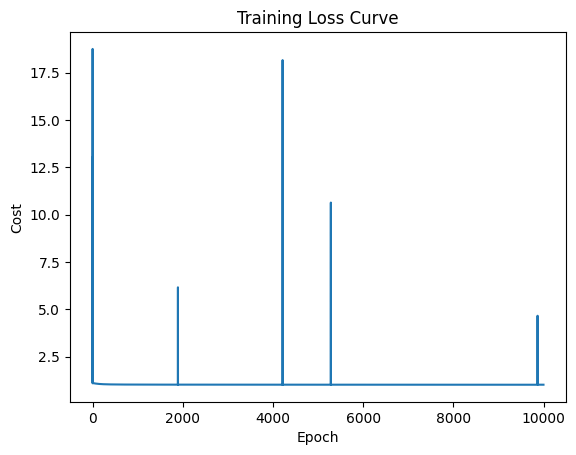

In [136]:
# 1. Build class mapping from labels
classes = sorted(y_train.unique())
class_to_int = {c: i for i, c in enumerate(classes)}
print("Class mapping:", class_to_int)

# 2. Convert string labels to integer indices
y_train_int = y_train.map(class_to_int).astype(int).values.reshape(-1)

# 3. One-hot encode
num_classes = len(class_to_int)
Y_train = np.eye(num_classes)[y_train_int].T

# 4. Transpose X for the neural network
X_train = X_train.T

# 5. Train neural network
IL = X_train.shape[0]
HL = 50
OL = num_classes

trained_parameters = train_neural_network(X_train, Y_train, IL, HL, OL, 10000)


##### Base Train Evaluated on Cost
After running the base model on $10000$ iterations we can make some assumtions regarding the cost values.  
- High cost on early runs.  
    This is to be expected since the initial weights are randomly assigned and we're using `Softmax` cross-entropy.
- Rapid drop in cost.  
    This is also expected since the model is most likely to establish potentially 'obvious' patterns early in the process.
- Spikes in cost through session.
    These spikes indicates momentary destabilization of the model.  
    Some of possible explenations for these spikes are:  
    * Weights grew too large.
    * Softmax saturated.
    * Gradient blew up or vanished.
    * Model collapsed back to trivial predictions.
- The gradient loss stagnates early in the run.  
    This might be the most important observation at this stage.  
    We can see in the print and the plot that after the first $100$ runs the cost value stagnates around $1$. This cost value indicates that our model is approximately close to doing random guesses on its predictions.  
    Considerations for a `Softmax` oriented ANN with $3$ classes:

    | Quality	| Cost value	|
    | :-------- | :------------ |
    | Perfect classifier | loss → 0 |
    | Random classifier | loss ≈ 1.10 |
    | Always predicting 1 class (majority collapse) | loss > 1.10 |

    This indicates a rather poor learning curve after the first $100$ runs.  
    One possible explanation for this is the uneven distributions of target values, meaning that the model start favoring the `Graduate` class at an early stage.

##### Evaluate predictions on Base Model
Based on the cost loss evaluation we're not expecting the best results at this stage.  
The model is expected to favor `Graduate` in it's prediction and thereby to do a lot of faulty predictions on the two other classes.  

To evaluate the predictions we'll be using `classification_report` and `confusion_matrix`.
- `classification_report`
    - Returns score values on the target classes precision, recall value and f1-score.
    - Returns an average score on accuracy, macro (averaging the unweighted mean per label) and weighted (averaging the support-weighted mean per label).
- `confusion_matrix`(with plot)
    - Gives a visual representation in the shape of a grid heatmap, that shows the distributions of predictions. With this we can more easily consider the validity of predictions.

              precision    recall  f1-score   support

     Dropout       0.76      0.03      0.06       427
    Enrolled       1.00      0.00      0.01       238
    Graduate       0.50      0.99      0.67       663

    accuracy                           0.51      1328
   macro avg       0.76      0.34      0.24      1328
weighted avg       0.68      0.51      0.35      1328



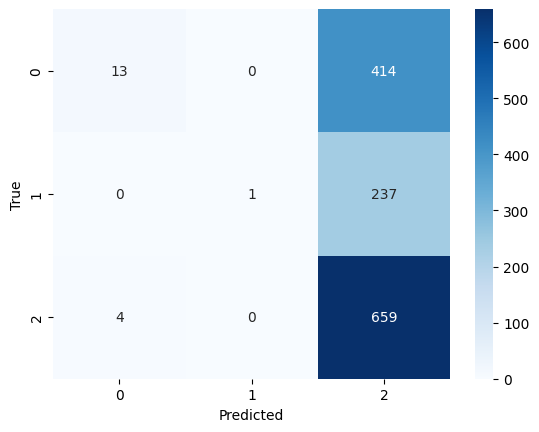

In [114]:
y_test_int = y_test.map(class_to_int).astype(int).values.reshape(-1)
predictions = predict(X_test.T, trained_parameters)

print(classification_report(y_test_int, predictions, target_names=classes))

cm = confusion_matrix(y_test_int, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##### Considering the Results on Base Predictions
As expected we can conduct that this models favors the `Graduate` class far to much to give accurate predictions.  
Right now almost every row is being classified as `Graduate`, which in turn results in about $50\%$ accuracy becuase of imbalanced classification in the data.  

- **Precision** (How many predicted positive for this class were actually correct?)  
    - **Dropout** = 0.76  
        * When model predicts Dropout, 76% are correct  
        * But it hardly predicts Dropout at all.  
    - **Enrolled** = 1.00  
        * It almost NEVER predicts this class  
        * So when it does predict it, it happens to be correct  
    - **Graduate** = 0.50  
        * Half of predicted Graduate samples are wrong  
        * This is typical when the model predicts this too often  
- **Recall** (How many true samples of this class did the model correctly detect?)  
    - **Dropout** = 0.03  
        * It finds only 3% of true Dropout students  
    - **Enrolled** = 0.00  
        * It completely fails to detect this class  
        * The model never predicts Enrolled  
    - **Graduate** = 0.99  
        * It predicts almost every sample as Graduate  
        * So of course recall is extremely high  
- **F1-score** (mean of precision and recall)  
    - **Dropout** = 0.06
    - **Enrolled** = 0.01
    - **Graduate** = 0.67
        * Graduate F1 is only high because recall is high.

#### Tuning
In this section we'll go through the process of trying to improve the precission on predictions.  
Here we'll do training over several steps where a tweak gets implemented for each stage.  

##### Normalizing Target Classes.
We'll start by normalizing the target classes so that we get a balanced distribution of targets to train on.  
This should eliminate the class favoritism which has been reducing the models prediction abilities in the base run.  
To acheive this we'll be using `StandardScaler` to standardize features by removing the mean and scaling to unit variance.  
Then we'll transpose the data to fit the training model once again.

##### Tuning Steps
Allready by normalizing we could observe a radical decrease in the gradient loss, which indicates a mutch better learning pattern than before.  
Without any further tuning the final cost value had been reduced from $1$ to about $0.4$.  
This was considered a stong indication that we're going in the right direction.  

The next steps where to tweak the parameters which was not beeing controlled inside the `HL` trough the activation functions.  
This gave three possible things to adjust the training process:
- Proportion split for train/test data.
- Number of neurons in `HL`.
- Number of runs in a training session(epochs).

Training set class distribution:
Target
Graduate    0.499354
Dropout     0.321059
Enrolled    0.179587
Name: count, dtype: float64
Test set class distribution:
Target
Graduate    0.499247
Dropout     0.321536
Enrolled    0.179217
Name: count, dtype: float64 

Train set shape:
 (3096, 36), (3096,)
Test set shape:
 (1328, 36), (1328,)
Epoch 0: Cost = 1.0982715342948186
Epoch 100: Cost = 1.0560240778895547
Epoch 200: Cost = 1.0287803842757464
Epoch 300: Cost = 0.9995753259171494
Epoch 400: Cost = 0.9517330144673879
Epoch 500: Cost = 0.8787794485807545
Epoch 600: Cost = 0.8048614356144248
Epoch 700: Cost = 0.7513576150334755
Epoch 800: Cost = 0.7144799207466885
Epoch 900: Cost = 0.6874913442953953
Epoch 1000: Cost = 0.6671438717562264
Epoch 1100: Cost = 0.6514776309942963
Epoch 1200: Cost = 0.6392035413739191
Epoch 1300: Cost = 0.6292893811252444
Epoch 1400: Cost = 0.6211108938467804
Epoch 1500: Cost = 0.6142675670948675
Epoch 1600: Cost = 0.6083783295598433
Epoch 1700: Cost = 0.6032358986

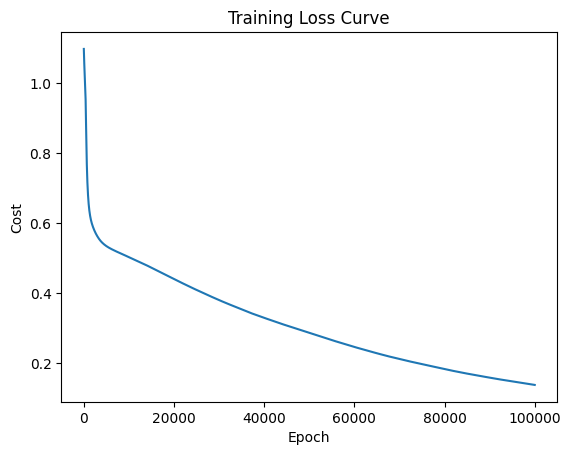

In [174]:
scaler = StandardScaler()

student_original_df = pd.read_csv('../data/student_predictions.csv', sep=';')
X_train, X_test, y_train, y_test = stvts(student_original_df, "Target", 0.3)

# Build mapping
classes = sorted(y_train.unique())
class_to_int = {c: i for i, c in enumerate(classes)}

# Convert labels to integers
y_train_int = y_train.map(class_to_int).astype(int).values.reshape(-1)

# One-hot encode
num_classes = len(class_to_int)
Y_train = np.eye(num_classes)[y_train_int].T

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled.T
X_test = X_test_scaled.T

IL = X_train.shape[0]
HL = 80
OL = num_classes

trained_parameters = train_neural_network(X_train, Y_train, IL, HL, OL, 100000)

##### Tuning Results
After runing through several loops with different values before moving on to predictions. We ended up with the following values which was considered the most effective solution that yielded the beste results:
- **Split Proportion**  
    Train/Test → $70/30$
- **Neurons for HL**  
    80
- **Epochs**  
    100000

Here are some of the plots for the **Training Loss Curve** that shows the different results from tuning the model:
<img src="img/2025-11-23_05-28-03.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_05-17-26.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_05-10-13.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_05-09-42.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_05-04-57.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_05-52-19.PNG" style="width:32%; height:auto;">
<img src="img/2025-11-23_06-30-01.PNG" style="width:32%; height:auto;">

              precision    recall  f1-score   support

     Dropout       0.72      0.71      0.72       427
    Enrolled       0.44      0.40      0.42       238
    Graduate       0.80      0.83      0.82       663

    accuracy                           0.72      1328
   macro avg       0.66      0.65      0.65      1328
weighted avg       0.71      0.72      0.71      1328



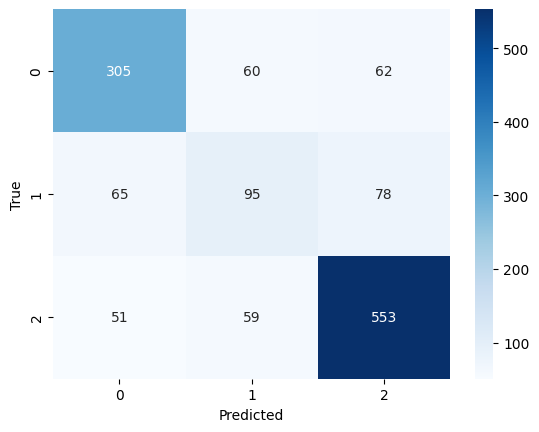

In [173]:
y_test_int = y_test.map(class_to_int).astype(int).values.reshape(-1)
predictions = predict(X_test, trained_parameters)

print(classification_report(y_test_int, predictions, target_names=classes))

cm = confusion_matrix(y_test_int, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##### Test Run on pre-processed Data
From the last assignment we found that the processing steps we preformed on this dataset didn't yield in any improvments for the model training.  
I would still like to test the results on this model with the processed data.  
For this run we'll be using what we found to be the best tuning for the original dataset and see if there is any improvement on the processed data.  
To make the comparison fair this data will also be normalized before the training run.

Training set class distribution:
Target
Graduate    0.499354
Dropout     0.321059
Enrolled    0.179587
Name: count, dtype: float64
Test set class distribution:
Target
Graduate    0.499247
Dropout     0.321536
Enrolled    0.179217
Name: count, dtype: float64 

Train set shape:
 (3096, 26), (3096,)
Test set shape:
 (1328, 26), (1328,)
Epoch 0: Cost = 1.0980954751422562
Epoch 100: Cost = 1.0574812113592524
Epoch 200: Cost = 1.0339651433363621
Epoch 300: Cost = 1.0153219132436382
Epoch 400: Cost = 0.991805133411403
Epoch 500: Cost = 0.9535588886463214
Epoch 600: Cost = 0.8954965450274123
Epoch 700: Cost = 0.8297745565152845
Epoch 800: Cost = 0.7761186582722509
Epoch 900: Cost = 0.7386139422098662
Epoch 1000: Cost = 0.7120649934047341
Epoch 1100: Cost = 0.6919534475866587
Epoch 1200: Cost = 0.6759824379009366
Epoch 1300: Cost = 0.6629400689900732
Epoch 1400: Cost = 0.6520725052079632
Epoch 1500: Cost = 0.642913993525401
Epoch 1600: Cost = 0.6351219576905331
Epoch 1700: Cost = 0.628415409211

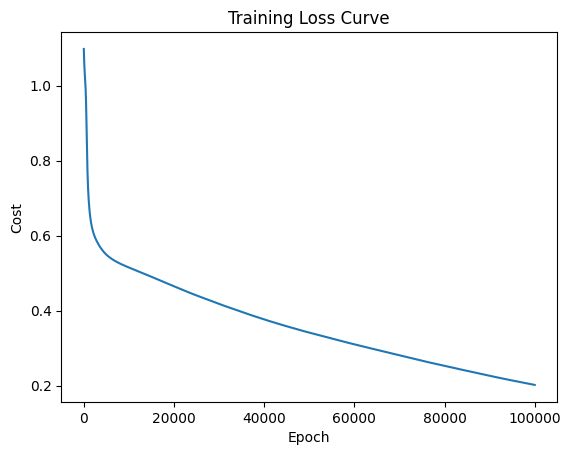

In [184]:

scaler = StandardScaler()

student_processed_df = pd.read_pickle('../data/student_predictions_processed.pkl')
X_train, X_test, y_train, y_test = stvts(student_processed_df, "Target", 0.3)

# Build mapping
classes = sorted(y_train.unique())
class_to_int = {c: i for i, c in enumerate(classes)}

# Convert labels to integers
y_train_int = y_train.map(class_to_int).astype(int).values.reshape(-1)

# One-hot encode
num_classes = len(class_to_int)
Y_train = np.eye(num_classes)[y_train_int].T

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled.T
X_test = X_test_scaled.T

IL = X_train.shape[0]
HL = 80
OL = num_classes

trained_parameters = train_neural_network(X_train, Y_train, IL, HL, OL, 100000)

##### Tuning Results
Based on the last run we can see that the gradient loss gives a sligtly worse score on the pre-processed data compared with the original dataset.  
This was to be expected since these results corresponds with the results from the earlier assigment for this datset.  
Based on the confusion matrix we can see that the overall quality of predictions are quite similar, but the processed does slightly poorer with more inaccurate predictions for `Dropout` and `Graduate` predictions.  
Both models struggle with predictions for the `Enrolled` class, which might indicate to few unique pattern to distinguish this target class from the two others.

              precision    recall  f1-score   support

     Dropout       0.75      0.70      0.72       427
    Enrolled       0.44      0.39      0.42       238
    Graduate       0.80      0.86      0.83       663

    accuracy                           0.72      1328
   macro avg       0.66      0.65      0.65      1328
weighted avg       0.72      0.72      0.72      1328



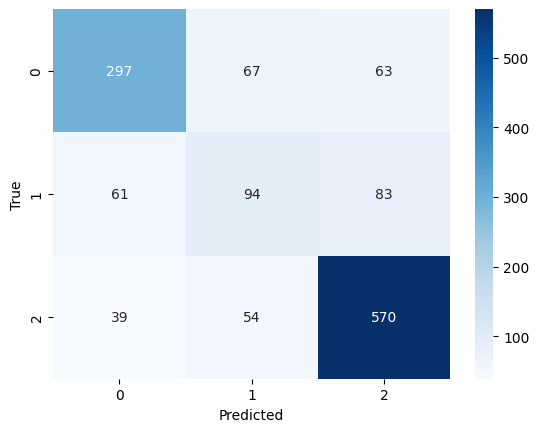

In [185]:
y_test_int = y_test.map(class_to_int).astype(int).values.reshape(-1)
predictions = predict(X_test, trained_parameters)

print(classification_report(y_test_int, predictions, target_names=classes))

cm = confusion_matrix(y_test_int, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Final Evaluation
After doing several runs in training and prediction we managed to bump the total accuracy from below $50\%$ to above $70\%$.  
This is a strong indication that we've successfully managed to improve the models prediction abilities, but we're still not in the ballpark of perfect predictions.  
There are major improvments on predictions for all three classes. Especially regarding `Dropout` and `Graduate`.  
Predictions for `Enrolled` have also increased a lot, but the model is struggeling with both false negatives and positives. At the best model this class is still predicted with about 1/3 even distribution between the classes. Which means it only gets about 1/3 of the predictions for this class. The fact that the distribution is so even between positive/negative false predictions, could indicate that the patterns for the features with this target class are quite similar to both the other classes which give the model a hard time to find good predictions on this target class.  

### Possible Further Steps
If I were to continue trying to improve this model, I would consider removing the `Enrolled` class from the dataset and change the output activation function from `Softmax` to `Sigmoid` so that we could test if the model would preform better with a binomial classification solution.  
I would then take the parameters from that result and see if there was a way to better separate `Enrolled` from the two other classes.